## RFM (Recency, Frequency, Monetary) analysis of randomly generated dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_transactions = pd.read_csv('/home/gabriel/Documents/GitHub/random-cohort-rfm-analysis/data/transactions.csv')
df_transactions['order_date'] = pd.to_datetime(df_transactions['order_date'])

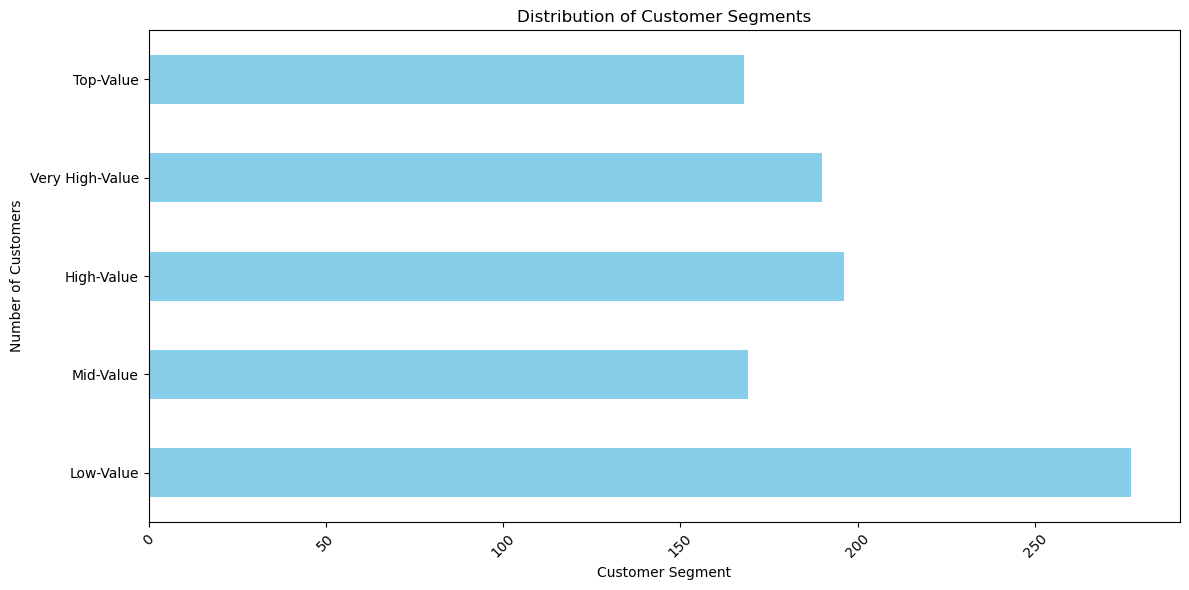

In [8]:
# to get the most recent date in the dataset 
most_recent_date = df_transactions['order_date'].max()

# constructing the RFM table
rfm_table = df_transactions.groupby('customer_id').agg({
    'order_date': lambda x: (most_recent_date - x.max()).days,
    'order_id': 'count',
    'order_amount': 'sum'
})

# renaming the columns of the RFM table
rfm_table.columns = ['Recency', 'Frequency', 'Monetary']

# generating RFM scores
rfm_table['r_score'] = pd.qcut(rfm_table['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm_table['f_score'] = pd.qcut(rfm_table['Frequency'], 5, labels=[1, 2, 3, 4, 5])
rfm_table['m_score'] = pd.qcut(rfm_table['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# generating the average rfm score for each customer
rfm_table['RFM_Score'] = round(rfm_table[['r_score', 'f_score', 'm_score']].mean(axis=1), 2)

# grouping customers into segments based on their RFM scores
rfm_table['Segment'] = pd.qcut(rfm_table['RFM_Score'], 5, labels=['Low-Value', 'Mid-Value', 'High-Value', 'Very High-Value', 'Top-Value'])

# visualizing the distribution of RFM scores
plt.figure(figsize=(12, 6))
segment_counts = rfm_table['Segment'].value_counts().sort_index()
segment_counts.plot(kind='barh', color='skyblue')
plt.title('Distribution of Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/home/gabriel/Documents/GitHub/random-cohort-rfm-analysis/graphs/segment_distribution.png')